# LFP model


doing some visualization while testing how best to train the LFP bandpower-matched models

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d

## Theta 4-8

In [ ]:
# THIS ONE LOOKS BEST, TRAINED WITH 30K TRIALS AND 1.5*OUTPUT + LFP LOSS -- TARGET THETA 4-8
model_dir = '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
model_fname = 'Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_19_003814.mat'
mat_data = scipy.io.loadmat(os.path.join(model_dir, model_fname))

## Alpha 9-12

In [ ]:
# 30K TRIALS, 1.5*OUTPUT + LFP LOSS -- TARGET ALPHA 9-12. note: this one looks weird normalized.
model_dir = '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
model_fname = 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_19_124334.mat'
mat_data = scipy.io.loadmat(os.path.join(model_dir, model_fname))

In [ ]:
# 30K TRIALS, 1.5*OUTPUT + LFP LOSS -- TARGET ALPHA 9-12. CHANGED BASELINE TO 25-50 INSTEAD OF 10-25
model_dir = '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
model_fname = '.mat'
mat_data = scipy.io.loadmat(os.path.join(model_dir, model_fname))

In [4]:
for keys in mat_data.keys():
    print(keys)

__header__
__version__
__globals__
x0
r0
w0
taus_gaus0
w_in0
u
o
w
x
target
lfp_power_target
epsp
w_out
r
m
som_m
N
exc
inh
w_in
b_out
som_N
losses
losses_out
losses_lfp
taus
eval_perf_mean
eval_loss_mean
eval_os
eval_labels
taus_gaus
tr
activation


In [5]:
mat_data['tr']

array([[11401]])

In [6]:
mat_data['eval_perf_mean']

array([[0.96]])

(2, 300)


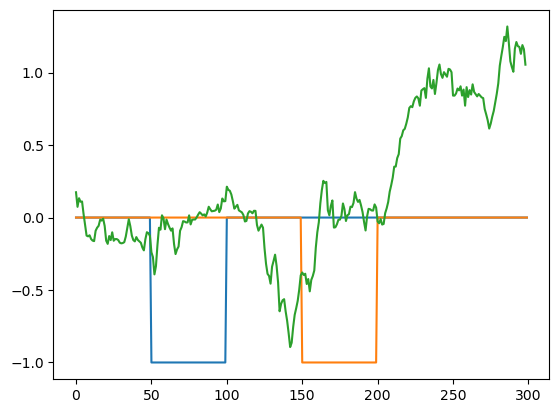

[]
[]


In [7]:
print(mat_data['u'].shape)
plt.plot(mat_data['u'].T)
plt.plot(np.squeeze(mat_data['o']))
plt.show()
print(np.where(mat_data['u'][0,:] > 0)[0])
print(np.where(mat_data['u'][1,:] > 0)[0])

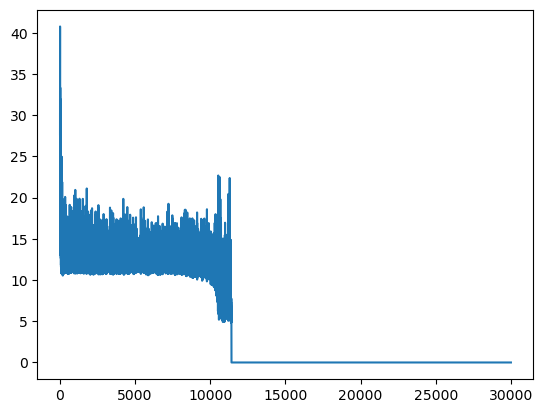

In [8]:
plt.plot(mat_data['losses'].T)
plt.show()

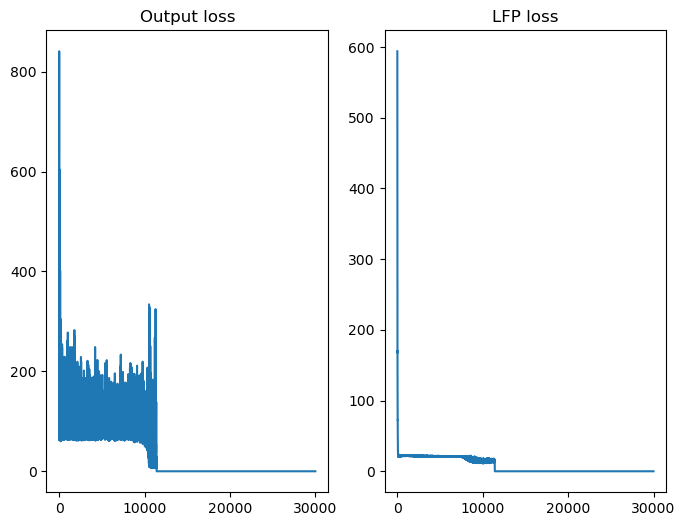

In [9]:
fig, axs = plt.subplots(1,2, figsize=(8,6))
axs[0].plot(mat_data['losses_out'].T)
axs[0].set_title('Output loss')
axs[1].plot(mat_data['losses_lfp'].T)
axs[1].set_title('LFP loss')
plt.show()

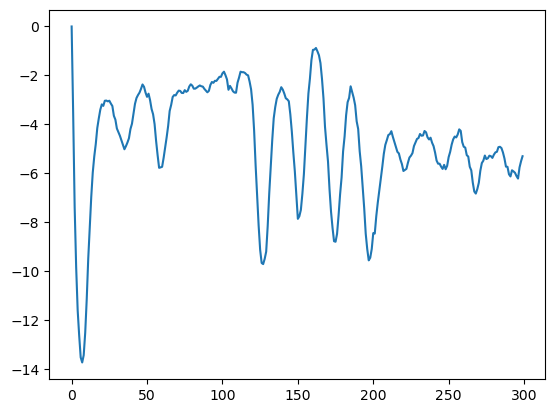

In [10]:
plt.plot(mat_data['x'][:,0,0].T)
plt.show()

#### Visualize outputs

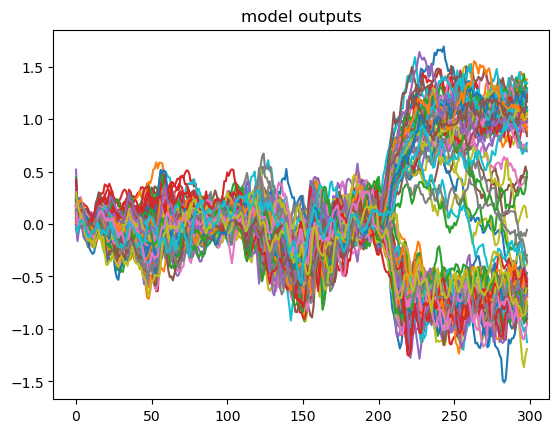

In [11]:
plt.figure()
plt.plot(np.transpose(mat_data['eval_os'][:,]))
plt.title('model outputs')
plt.show()

#### plot spect lol

(300, 1)


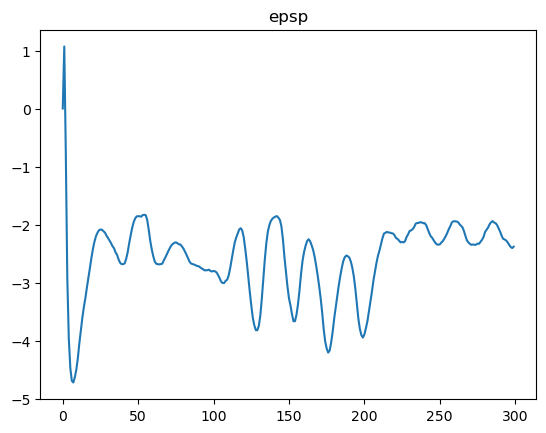

In [12]:
epsp = mat_data['epsp']
print(epsp.shape)
plt.plot(epsp)
plt.title('epsp');

In [13]:
settings = {
            'T': 300, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 50, # input stim duration (in steps)
            'delay': 50, # delay b/w the two stimuli (in steps)
            'DeltaT': 1, # sampling rate
            'fs': 200, # sampling rate (Hz)
            'taus': [4, 25], # decay time-constants (in steps)
            'lfp_power_target': [4, 8], # target power for the LFP
            'task': 'xor', # task name
            }

In [14]:
mat_data['lfp_power_target']

array([[ 9., 12.]])

2025-08-19 14:01:12.767436: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-19 14:01:12.776377: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-19 14:01:12.787088: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-19 14:01:12.790248: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-19 14:01:12.799962: I tensorflow/core/platform/cpu_feature_guar

Instructions for updating:
non-resource variables are not supported in the long term
(300,)


I0000 00:00:1755626473.930299  558680 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1755626473.930522  558680 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1755626473.930677  558680 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-08-19 14:01:13.965727: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen s

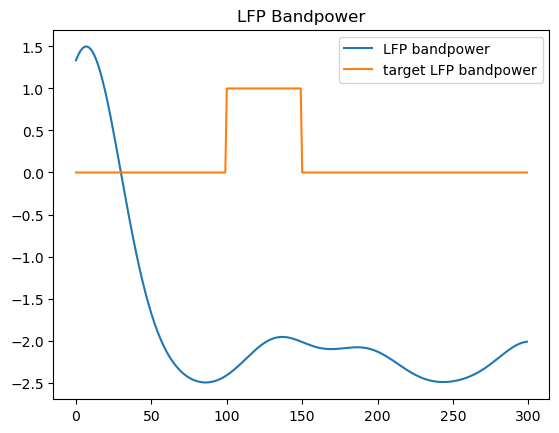

In [15]:
# plot bandpower

import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
from model import calculate_LFP_bandpower, generate_target_LFP_bandpower

bandpower = calculate_LFP_bandpower(settings, epsp)
import tensorflow.compat.v1 as tf
with tf.Session() as sess:
    lfp_bandpower = sess.run(bandpower)
print(lfp_bandpower.shape)
y = generate_target_LFP_bandpower(settings)

plt.figure()
plt.plot(lfp_bandpower, label='LFP bandpower')
plt.plot(y, label='target LFP bandpower')
plt.legend()
plt.title('LFP Bandpower');

In [ ]:
# ---- settings ----
T         = settings['T']
fs        = settings['fs']           # Hz
dt        = 1.0 / fs
fmin, fmax = 4.0, 100.0
num_freqs = 40
band_lo, band_hi = settings['lfp_power_target']  # e.g., [30, 80]
stim_on   = settings['stim_on']

# ---- epsp -> shape [1, T, 1] ----
# epsp is length T, each element shape [1,1], so squeeze & stack:
# pdb.set_trace()
epsp_vec = tf.squeeze(tf.stack(epsp, axis=0))          # [T] or [T,] float32
epsp_sig = tf.reshape(epsp_vec, [1, T, 1])                   # [batch=1, time=T, ch=1]

# ---- frequencies & scales ----
freqs = tf.exp(tf.linspace(tf.log(fmin), tf.log(fmax), num_freqs))  # [num_freqs]
# Morlet central frequency for PyWavelets 'morl' ~ 0.8125, but we can treat as hyperparam.
# Match PyWavelets by using that same fc:
fc = tf.constant(0.8125, dtype=tf.float32)
scales = fc / (freqs * dt)                                   # [num_freqs]

# ---- build Morlet kernels (real & imag) ----
# Window length: K cycles of the center frequency at each scale.
# K=6 is a common choice. Use time support symmetric around 0.
K = 6.0
# For a Morlet at frequency f, approximate sigma_t ~ K/(2*pi*f)
# Use a *shared* max half-width across freqs for "same" padding kernels.
# Choose a kernel that covers the lowest freq sufficiently:
f_low = fmin
sigma_t_low = K / (2.0 * np.pi * f_low)
half_width_sec = 4.0 * sigma_t_low   # ~±4 sigma
kernel_len = tf.cast(tf.round(2.0 * half_width_sec * fs) + 1, tf.int32)  # odd length
kernel_len = tf.maximum(kernel_len, 31)  # avoid too-short kernels
# time vector centered at 0
t_idx = tf.range(kernel_len, dtype=tf.float32) - tf.cast(kernel_len - 1, tf.float32)/2.0
t_sec = t_idx / fs  # [L]

# Morlet wavelet (complex): psi(t; f) = A * exp(-t^2/(2*sigma^2)) * exp(2j*pi*f*t)
# We normalize each kernel to unit L2 energy so power is comparable across freqs.
# Build per-frequency kernels (broadcast over [L, num_freqs]).
two_pi = tf.constant(2.0*np.pi, tf.float32)
# sigma_t per frequency (vector) — wider at low freq:
sigma_t = K / (two_pi * freqs)  # [num_freqs]
# Gaussian envelope
env = tf.exp(-0.5 * tf.square(tf.expand_dims(t_sec,1) / tf.expand_dims(sigma_t,0)))  # [L, F]
# carrier
phase = two_pi * tf.expand_dims(t_sec,1) * tf.expand_dims(freqs,0)                   # [L, F]
cos_part = env * tf.cos(phase)                                                       # [L, F]
sin_part = env * tf.sin(phase)                                                       # [L, F]

# L2 normalize each frequency kernel
eps = 1e-8
norm = tf.sqrt(tf.reduce_sum(tf.square(cos_part) + tf.square(sin_part), axis=0, keepdims=True) + eps)  # [1,F]
cos_part = cos_part / norm
sin_part = sin_part / norm

# conv1d wants [filter_width, in_channels, out_channels]
# in_channels=1; out_channels=F (one filter per frequency)
cos_filt = tf.expand_dims(cos_part, 1)  # [L,1,F]
sin_filt = tf.expand_dims(sin_part, 1)  # [L,1,F]

# ---- convolution: "SAME" to keep T ----
real_coeff = tf.nn.conv1d(epsp_sig, cos_filt, stride=1, padding='SAME')  # [1,T,F]
imag_coeff = tf.nn.conv1d(epsp_sig, sin_filt, stride=1, padding='SAME')  # [1,T,F]

power = tf.square(real_coeff) + tf.square(imag_coeff)  # [1,T,F]
power = tf.squeeze(power, axis=0)                      # [T,F]

# ---- select target band & average across freqs in band ----
band_mask = tf.logical_and(freqs >= band_lo, freqs <= band_hi)         # [F]
band_mask_f = tf.cast(band_mask, tf.float32)
# Avoid empty band:
denom = tf.maximum(tf.reduce_sum(band_mask_f), 1.0)
band_power = tf.tensordot(power, band_mask_f/denom, axes=[[1],[0]])    # [T]

# ---- baseline z-score (pure TF) ----
# baseline: e.g., indices 25 : stim_on (exclusive)
start = tf.constant(25, dtype=tf.int32)
stop  = tf.cast(stim_on, tf.int32)
base_slice = band_power[start:stop]                                     # [stop-start]
base_mean  = tf.reduce_mean(base_slice)
base_std   = tf.math.reduce_std(base_slice) + 1e-8
lfp_power_z = (band_power - base_mean) / base_std                       # [T]



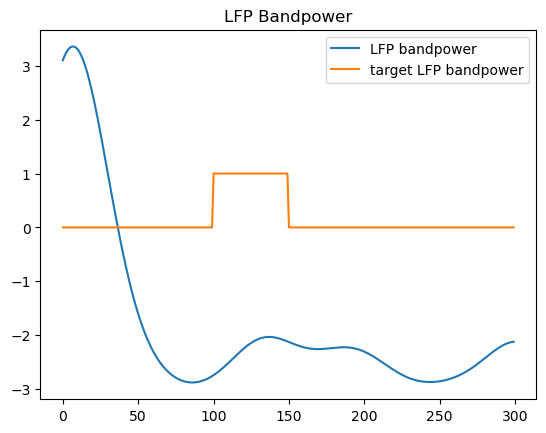

In [23]:
with tf.Session() as sess:
    lfp_power_z = sess.run(lfp_power_z)
    
plt.figure()
plt.plot(lfp_power_z, label='LFP bandpower')
plt.plot(y, label='target LFP bandpower')
plt.legend()
plt.title('LFP Bandpower');

In [24]:
with tf.Session() as sess:
    power, freqs = sess.run([power, freqs])

In [18]:
print(power.shape, freqs.shape)

(300, 40) (40,)


In [19]:
freqs

array([  4.       ,   4.3441477,   4.717905 ,   5.1238194,   5.564657 ,
         6.0434237,   6.5633826,   7.128076 ,   7.741353 ,   8.407395 ,
         9.130743 ,   9.9163265,  10.769497 ,  11.696072 ,  12.702367 ,
        13.795239 ,  14.982141 ,  16.271158 ,  17.67108  ,  19.191446 ,
        20.84262  ,  22.635862 ,  24.583382 ,  26.698462 ,  28.995518 ,
        31.490204 ,  34.199524 ,  37.14195  ,  40.337532 ,  43.80805  ,
        47.57716  ,  51.670555 ,  56.116135 ,  60.944195 ,  66.18765  ,
        71.88223  ,  78.066765 ,  84.783394 ,  92.0779   , 100.00001  ],
      dtype=float32)

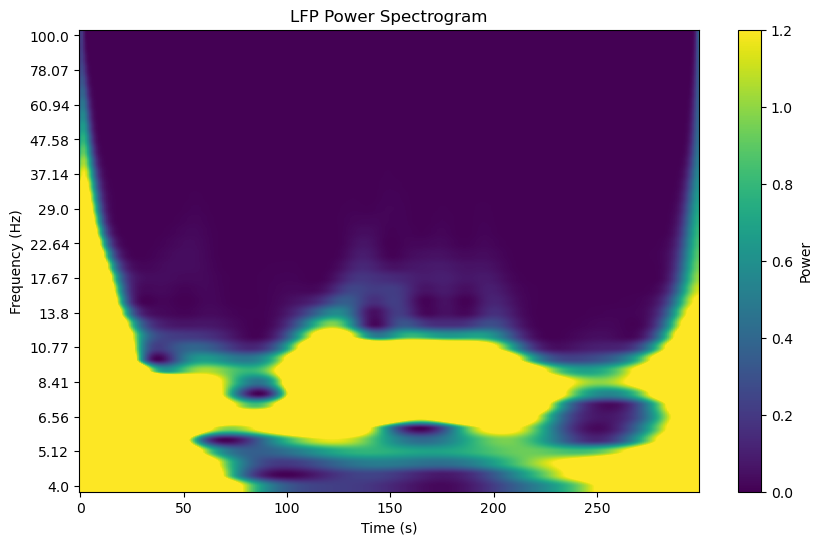

In [25]:
# plot power as spectrogram

time_cutoff = 25

plt.figure(figsize=(10, 6))
# plt.imshow(power[time_cutoff:,:].T, aspect='auto', extent=[time_cutoff, T, fmin, fmax], origin='lower',
#            vmin=0, vmax=1.2)
plt.imshow(power.T, aspect='auto', origin='lower',
           vmin=0, vmax=1.2)
# plt.axhline(y=band_lo, color='r', linestyle='--', label='Band low')
# plt.axhline(y=band_hi, color='r', linestyle='--', label='Band high')
plt.yticks()
plt.yticks(np.arange(0, num_freqs, 3), np.round(freqs[::3], 2))
plt.colorbar(label='Power')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('LFP Power Spectrogram')
plt.show()

## Beta 13-30

In [ ]:
# 30K TRIALS, 1.5*OUTPUT + LFP LOSS -- TARGET BETA 13-30. note: this one didn't finish training
model_dir = '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
model_fname = 'Task_xor_N_200_Taus_4.0_25.0_LFP_13.0_30.0_Act_sigmoid_2025_08_19_134141'
mat_data = scipy.io.loadmat(os.path.join(model_dir, model_fname))

In [ ]:
# 30K TRIALS, 1.5*OUTPUT + LFP LOSS -- TARGET BETA 13-30. this one finished.
model_dir = '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
model_fname = 'Task_xor_N_200_Taus_4.0_25.0_LFP_13.0_30.0_Act_sigmoid_2025_08_19_151253'
mat_data = scipy.io.loadmat(os.path.join(model_dir, model_fname))

In [36]:
for keys in mat_data.keys():
    print(keys)

__header__
__version__
__globals__
x0
r0
w0
taus_gaus0
w_in0
u
o
w
x
target
lfp_power_target
epsp
w_out
r
m
som_m
N
exc
inh
w_in
b_out
som_N
losses
losses_out
losses_lfp
taus
eval_perf_mean
eval_loss_mean
eval_os
eval_labels
taus_gaus
tr
activation


In [37]:
mat_data['tr']

array([[22401]])

In [38]:
mat_data['eval_perf_mean']

array([[0.99]])

(2, 300)


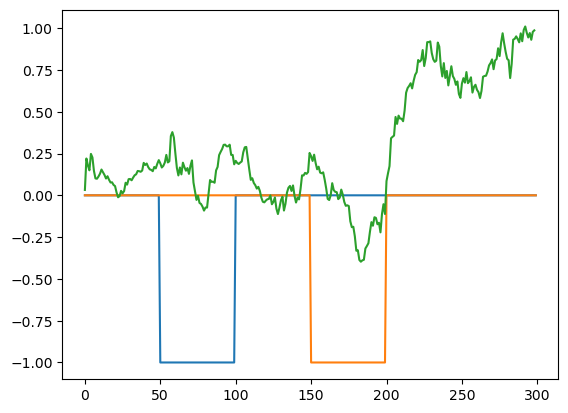

[]
[]


In [39]:
print(mat_data['u'].shape)
plt.plot(mat_data['u'].T)
plt.plot(np.squeeze(mat_data['o']))
plt.show()
print(np.where(mat_data['u'][0,:] > 0)[0])
print(np.where(mat_data['u'][1,:] > 0)[0])

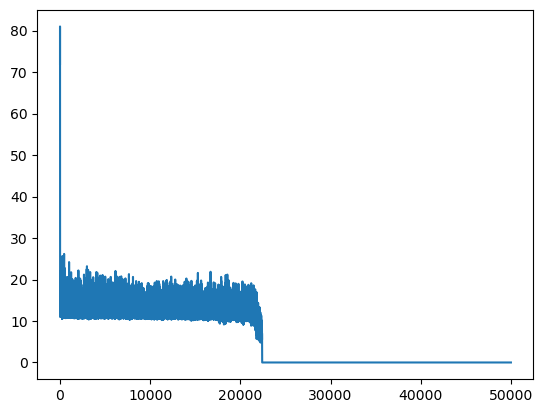

In [40]:
plt.plot(mat_data['losses'].T)
plt.show()

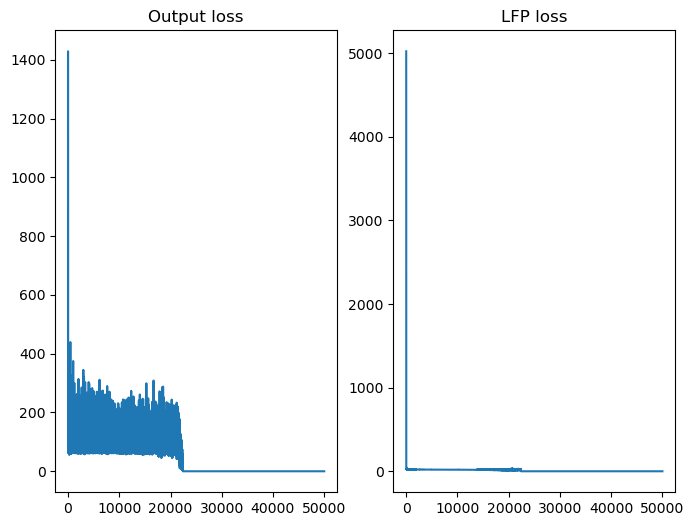

In [41]:
fig, axs = plt.subplots(1,2, figsize=(8,6))
axs[0].plot(mat_data['losses_out'].T)
axs[0].set_title('Output loss')
axs[1].plot(mat_data['losses_lfp'].T)
axs[1].set_title('LFP loss')
plt.show()

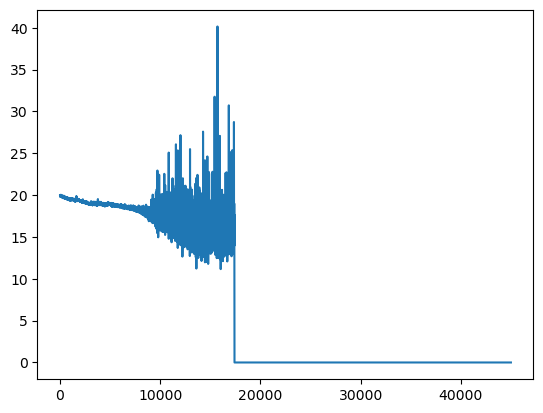

In [42]:
plt.plot(mat_data['losses_lfp'][:,5000:].T)

In [ ]:
mat_data['x'].shape

(300, 200, 1)

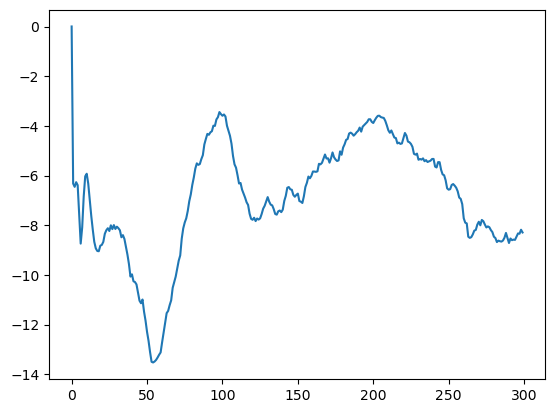

In [43]:
plt.plot(mat_data['x'][:,0,0].T)
plt.show()

### Visualize outputs

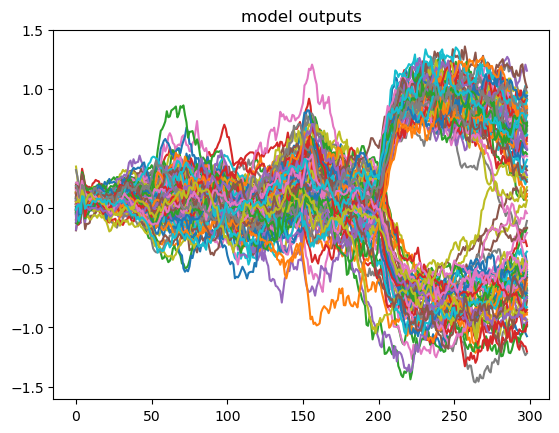

In [44]:
plt.figure()
plt.plot(np.transpose(mat_data['eval_os'][:,]))
plt.title('model outputs')
plt.show()

### plot spect lol

(300, 1)


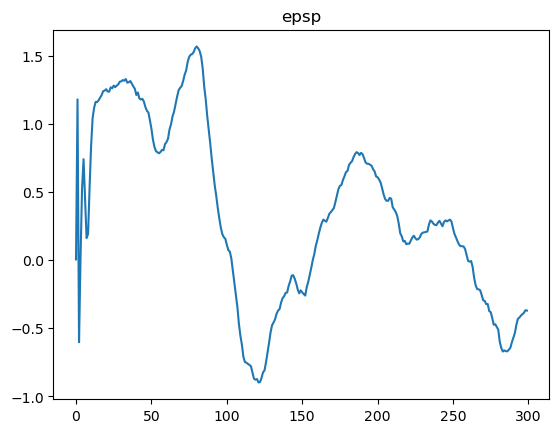

In [45]:
epsp = mat_data['epsp']
print(epsp.shape)
plt.plot(epsp)
plt.title('epsp');

In [46]:
settings = {
            'T': 300, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 50, # input stim duration (in steps)
            'delay': 50, # delay b/w the two stimuli (in steps)
            'DeltaT': 1, # sampling rate
            'fs': 200, # sampling rate (Hz)
            'taus': [4, 25], # decay time-constants (in steps)
            'lfp_power_target': [4, 8], # target power for the LFP
            'task': 'xor', # task name
            }

In [47]:
mat_data['lfp_power_target']

array([[13., 30.]])

(300,)


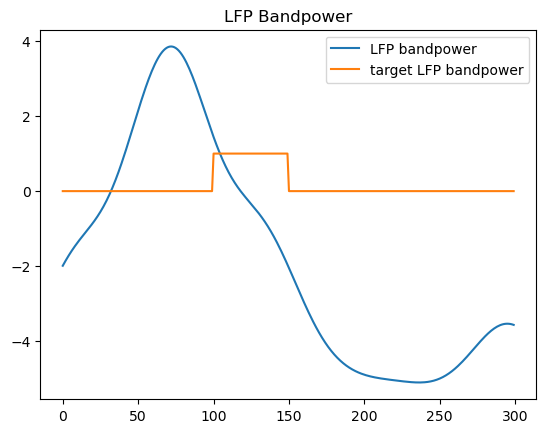

In [48]:
# plot bandpower

import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
from model import calculate_LFP_bandpower, generate_target_LFP_bandpower

bandpower = calculate_LFP_bandpower(settings, epsp)
import tensorflow.compat.v1 as tf
with tf.Session() as sess:
    lfp_bandpower = sess.run(bandpower)
print(lfp_bandpower.shape)
y = generate_target_LFP_bandpower(settings)

plt.figure()
plt.plot(lfp_bandpower, label='LFP bandpower')
plt.plot(y, label='target LFP bandpower')
plt.legend()
plt.title('LFP Bandpower');

In [49]:
# ---- settings ----
T         = settings['T']
fs        = settings['fs']           # Hz
dt        = 1.0 / fs
fmin, fmax = 4.0, 100.0
num_freqs = 40
band_lo, band_hi = settings['lfp_power_target']  # e.g., [30, 80]
stim_on   = settings['stim_on']

# ---- epsp -> shape [1, T, 1] ----
# epsp is length T, each element shape [1,1], so squeeze & stack:
# pdb.set_trace()
epsp_vec = tf.squeeze(tf.stack(epsp, axis=0))          # [T] or [T,] float32
epsp_sig = tf.reshape(epsp_vec, [1, T, 1])                   # [batch=1, time=T, ch=1]

# ---- frequencies & scales ----
freqs = tf.exp(tf.linspace(tf.log(fmin), tf.log(fmax), num_freqs))  # [num_freqs]
# Morlet central frequency for PyWavelets 'morl' ~ 0.8125, but we can treat as hyperparam.
# Match PyWavelets by using that same fc:
fc = tf.constant(0.8125, dtype=tf.float32)
scales = fc / (freqs * dt)                                   # [num_freqs]

# ---- build Morlet kernels (real & imag) ----
# Window length: K cycles of the center frequency at each scale.
# K=6 is a common choice. Use time support symmetric around 0.
K = 6.0
# For a Morlet at frequency f, approximate sigma_t ~ K/(2*pi*f)
# Use a *shared* max half-width across freqs for "same" padding kernels.
# Choose a kernel that covers the lowest freq sufficiently:
f_low = fmin
sigma_t_low = K / (2.0 * np.pi * f_low)
half_width_sec = 4.0 * sigma_t_low   # ~±4 sigma
kernel_len = tf.cast(tf.round(2.0 * half_width_sec * fs) + 1, tf.int32)  # odd length
kernel_len = tf.maximum(kernel_len, 31)  # avoid too-short kernels
# time vector centered at 0
t_idx = tf.range(kernel_len, dtype=tf.float32) - tf.cast(kernel_len - 1, tf.float32)/2.0
t_sec = t_idx / fs  # [L]

# Morlet wavelet (complex): psi(t; f) = A * exp(-t^2/(2*sigma^2)) * exp(2j*pi*f*t)
# We normalize each kernel to unit L2 energy so power is comparable across freqs.
# Build per-frequency kernels (broadcast over [L, num_freqs]).
two_pi = tf.constant(2.0*np.pi, tf.float32)
# sigma_t per frequency (vector) — wider at low freq:
sigma_t = K / (two_pi * freqs)  # [num_freqs]
# Gaussian envelope
env = tf.exp(-0.5 * tf.square(tf.expand_dims(t_sec,1) / tf.expand_dims(sigma_t,0)))  # [L, F]
# carrier
phase = two_pi * tf.expand_dims(t_sec,1) * tf.expand_dims(freqs,0)                   # [L, F]
cos_part = env * tf.cos(phase)                                                       # [L, F]
sin_part = env * tf.sin(phase)                                                       # [L, F]

# L2 normalize each frequency kernel
eps = 1e-8
norm = tf.sqrt(tf.reduce_sum(tf.square(cos_part) + tf.square(sin_part), axis=0, keepdims=True) + eps)  # [1,F]
cos_part = cos_part / norm
sin_part = sin_part / norm

# conv1d wants [filter_width, in_channels, out_channels]
# in_channels=1; out_channels=F (one filter per frequency)
cos_filt = tf.expand_dims(cos_part, 1)  # [L,1,F]
sin_filt = tf.expand_dims(sin_part, 1)  # [L,1,F]

# ---- convolution: "SAME" to keep T ----
real_coeff = tf.nn.conv1d(epsp_sig, cos_filt, stride=1, padding='SAME')  # [1,T,F]
imag_coeff = tf.nn.conv1d(epsp_sig, sin_filt, stride=1, padding='SAME')  # [1,T,F]

power = tf.square(real_coeff) + tf.square(imag_coeff)  # [1,T,F]
power = tf.squeeze(power, axis=0)                      # [T,F]

# ---- select target band & average across freqs in band ----
band_mask = tf.logical_and(freqs >= band_lo, freqs <= band_hi)         # [F]
band_mask_f = tf.cast(band_mask, tf.float32)
# Avoid empty band:
denom = tf.maximum(tf.reduce_sum(band_mask_f), 1.0)
band_power = tf.tensordot(power, band_mask_f/denom, axes=[[1],[0]])    # [T]

# ---- baseline z-score (pure TF) ----
# baseline: e.g., indices 10 : stim_on (exclusive)
start = tf.constant(10, dtype=tf.int32)
stop  = tf.cast(stim_on, tf.int32)
base_slice = band_power[start:stop]                                     # [stop-start]
base_mean  = tf.reduce_mean(base_slice)
base_std   = tf.math.reduce_std(base_slice) + 1e-8
lfp_power_z = (band_power - base_mean) / base_std                       # [T]



In [50]:
with tf.Session() as sess:
    power, freqs = sess.run([power, freqs])

In [51]:
print(power.shape, freqs.shape)

(300, 40) (40,)


In [52]:
freqs

array([  4.       ,   4.3441477,   4.717905 ,   5.1238194,   5.564657 ,
         6.0434237,   6.5633826,   7.128076 ,   7.741353 ,   8.407395 ,
         9.130743 ,   9.9163265,  10.769497 ,  11.696072 ,  12.702367 ,
        13.795239 ,  14.982141 ,  16.271158 ,  17.67108  ,  19.191446 ,
        20.84262  ,  22.635862 ,  24.583382 ,  26.698462 ,  28.995518 ,
        31.490204 ,  34.199524 ,  37.14195  ,  40.337532 ,  43.80805  ,
        47.57716  ,  51.670555 ,  56.116135 ,  60.944195 ,  66.18765  ,
        71.88223  ,  78.066765 ,  84.783394 ,  92.0779   , 100.00001  ],
      dtype=float32)

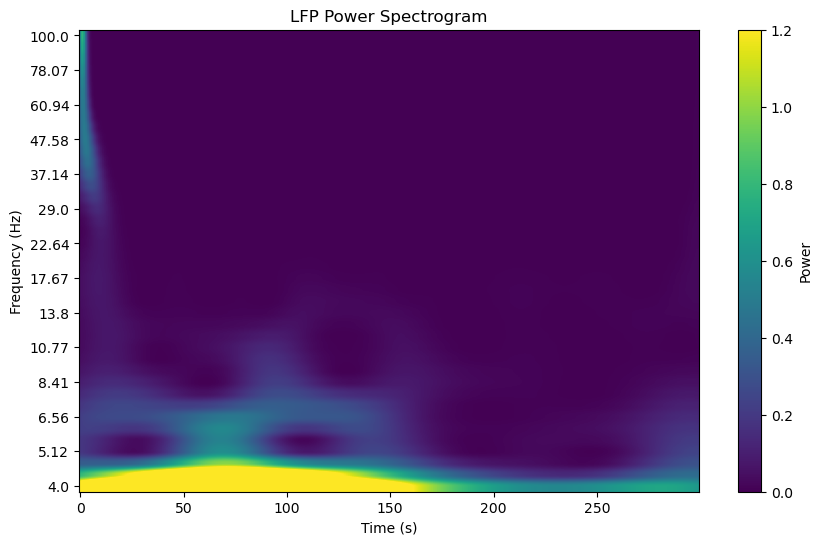

In [53]:
# plot power as spectrogram

time_cutoff = 25

plt.figure(figsize=(10, 6))
# plt.imshow(power[time_cutoff:,:].T, aspect='auto', extent=[time_cutoff, T, fmin, fmax], origin='lower',
#            vmin=0, vmax=1.2)
plt.imshow(power.T, aspect='auto', origin='lower',
           vmin=0, vmax=1.2)
# plt.axhline(y=band_lo, color='r', linestyle='--', label='Band low')
# plt.axhline(y=band_hi, color='r', linestyle='--', label='Band high')
plt.yticks()
plt.yticks(np.arange(0, num_freqs, 3), np.round(freqs[::3], 2))
plt.colorbar(label='Power')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('LFP Power Spectrogram')
plt.show()